# PolarGAP aeromagnetic levelling

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import cmocean
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()

## Load data

In [2]:
data_df = pd.read_csv("data/PolarGAP_magnetic_survey_blocked.csv")

data_df = data_df.drop(columns="line")

data_df = data_df.rename(
    columns={
        "MagB30RTC": "unlevelled_tfa",
        "MagL_B30RTC": "published_levelled_tfa",
    }
)

data_df = data_df[
    [
        "easting",
        "northing",
        "Elev",
        "distance_along_flight",
        "unixtime",
        "flight",
        "published_levelling_correction",
        "unlevelled_tfa",
        "published_levelled_tfa",
    ]
]

data_df = data_df.sort_values(["flight", "unixtime"])
data_df = data_df.dropna(subset=["unlevelled_tfa", "Elev"], how="any")

data_df.head()

,easting,northing,Elev,distance_along_flight,unixtime,flight,published_levelling_correction,unlevelled_tfa,published_levelled_tfa
6,-726977.495045,741483.042592,423.460,3247.624650,1.450202e+09,1,0.0,-83.880,-83.880
7,-726470.616701,741599.990804,463.925,3767.844206,1.450202e+09,1,0.0,-82.915,-82.915
8,-725988.389576,741687.954909,498.990,4258.101493,1.450202e+09,1,0.0,-84.850,-84.850
9,-725519.822728,741766.773750,524.450,4733.254367,1.450202e+09,1,0.0,-85.960,-85.960
10,-725011.350434,741849.901747,552.655,5248.482927,1.450202e+09,1,0.0,-86.505,-86.505


In [ ]:
# Wrap loaded data in a Survey object
survey = airbornegeo.Survey(
    data_df,
    line_column="flight",
    distance_column="distance_along_flight",
)
survey

In [3]:
data_df.describe()

,easting,northing,Elev,distance_along_flight,unixtime,flight,published_levelling_correction,unlevelled_tfa,published_levelled_tfa
count,64895.000000,64895.000000,64895.000000,6.489500e+04,6.489500e+04,64895.000000,64895.000000,64895.000000,64895.000000
mean,-105541.066793,205563.587994,2919.828885,5.007962e+05,1.451686e+09,18.412867,-0.606166,-7.212939,-7.819175
std,292675.389379,309282.559911,456.844799,2.844486e+05,8.926196e+05,10.204416,23.026873,80.326959,78.139104
min,-726977.495045,-486226.506678,423.460000,2.380619e+02,1.450202e+09,1.000000,-165.330000,-358.670000,-358.670000
25%,-371123.439905,-24624.796781,2806.292500,2.587746e+05,1.451050e+09,10.000000,-10.820000,-60.450000,-59.590000
50%,-63879.450095,152635.147254,2927.190000,4.882867e+05,1.451600e+09,18.000000,0.000000,-22.250000,-22.860000
75%,142273.736001,443415.225314,3211.560000,7.356324e+05,1.452472e+09,27.000000,9.100000,32.980000,28.435000
max,481430.890988,876164.436520,4326.505000,1.094965e+06,1.453326e+09,36.000000,154.105000,535.490000,545.605000


In [ ]:
survey.plot(color_by="flight", cmap="rainbow", title="Flights", s=0.02)

# Cross-over levelling

## Find intersections

In [ ]:
survey.create_intersection_table(
    method="network",
    buffer_dist=500,
    proximity_dist=500,
    cutoff_dist=1e3,
    block_size=5e3,
    min_spacing=10e3,
)
inters = survey.intersections
inters

In [ ]:
survey.lines_without_intersections()

Text(0.5, 1.0, 'Histogram of max distance between intersection and data')

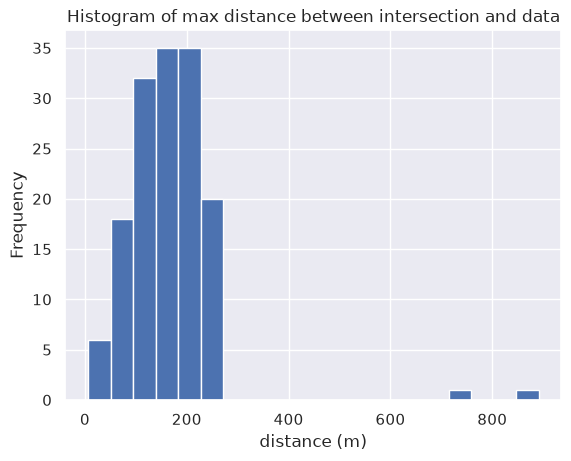

In [7]:
ax = inters.max_dist.plot.hist(bins=20)
ax.set_xlabel("distance (m)")
ax.set_title("Histogram of max distance between intersection and data")

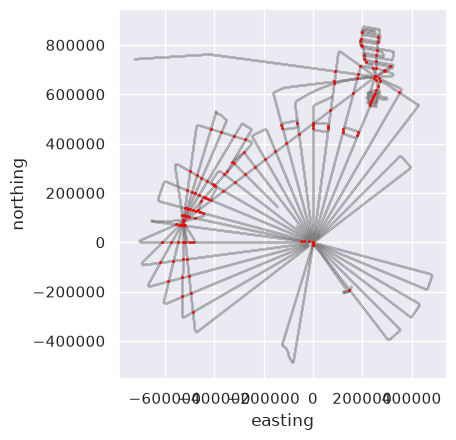

In [8]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    color="gray",
    s=0.001,
)
inters.plot.scatter(
    "easting",
    "northing",
    color="red",
    s=1,
    ax=ax,
)
ax.set_aspect("equal")

## Add intersections as rows to the dataframe

In [ ]:
survey.interpolate_intersections(
    to_interp="unlevelled_tfa",
    interp_on="distance_along_flight",
    method="linear",
    extrapolate=True,
)
inters = survey.intersections
inters

In [ ]:
survey.lines_without_intersections()

## Calculate initial cross-over errors

In [ ]:
survey.calculate_crossover_errors(
    data_col="unlevelled_tfa",
)
inters = survey.intersections
inters.head()

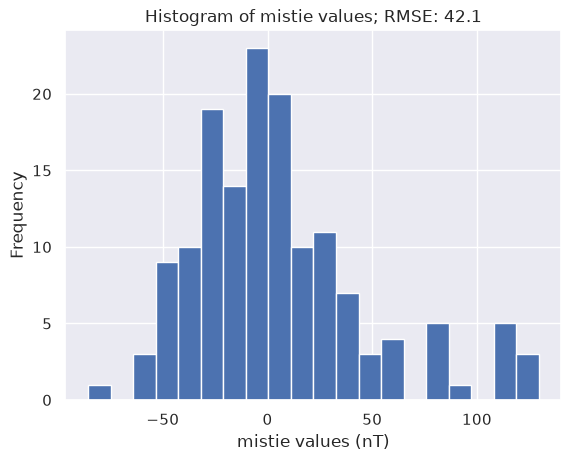

In [12]:
ax = inters.crossover_error_0.plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters.crossover_error_0), 2)}"
);

In [15]:
fig = airbornegeo.plotly_points(
    data_df,
    color_col="unlevelled_tfa",
    hover_cols=["flight"],
    cmap="viridis",
    size=3,
)
fig = airbornegeo.plotly_points(
    inters,
    fig=fig,
    color_col=inters.columns[-1],
    hover_cols=["line1", "line2", "is_buffered"],
    size=8,
    edge_width=0.2,
    cmap="balance",
    robust=False,
)

fig.show()

## Level with a trend

In [ ]:
survey.crossover_network_levelling(
    data_col="unlevelled_tfa",
    levelled_col="levelled_trend",
    degree=1,
    max_iterations=20,
    plot_dynamic_convergence=True,
)
inters_trend = survey.intersections

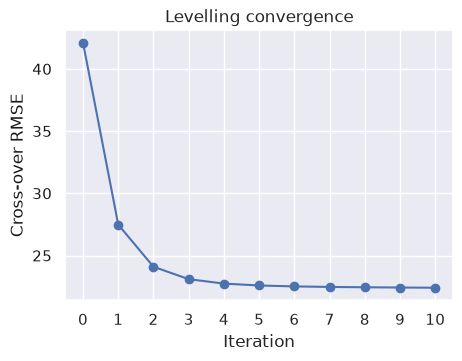

In [17]:
airbornegeo.plot_levelling_convergence(inters_trend)

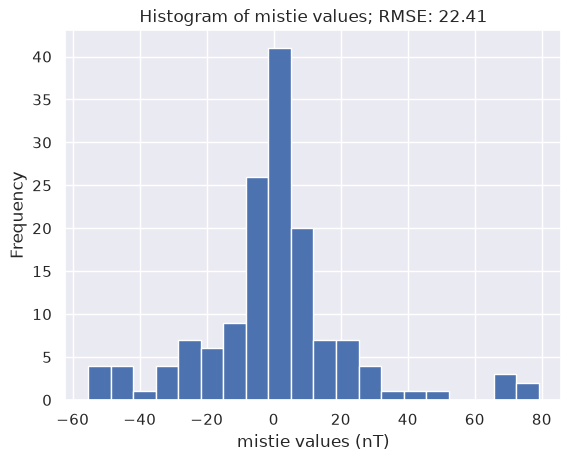

In [18]:
ax = inters_trend[inters_trend.columns[-1]].plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters_trend[inters_trend.columns[-1]]), 2)}"
);

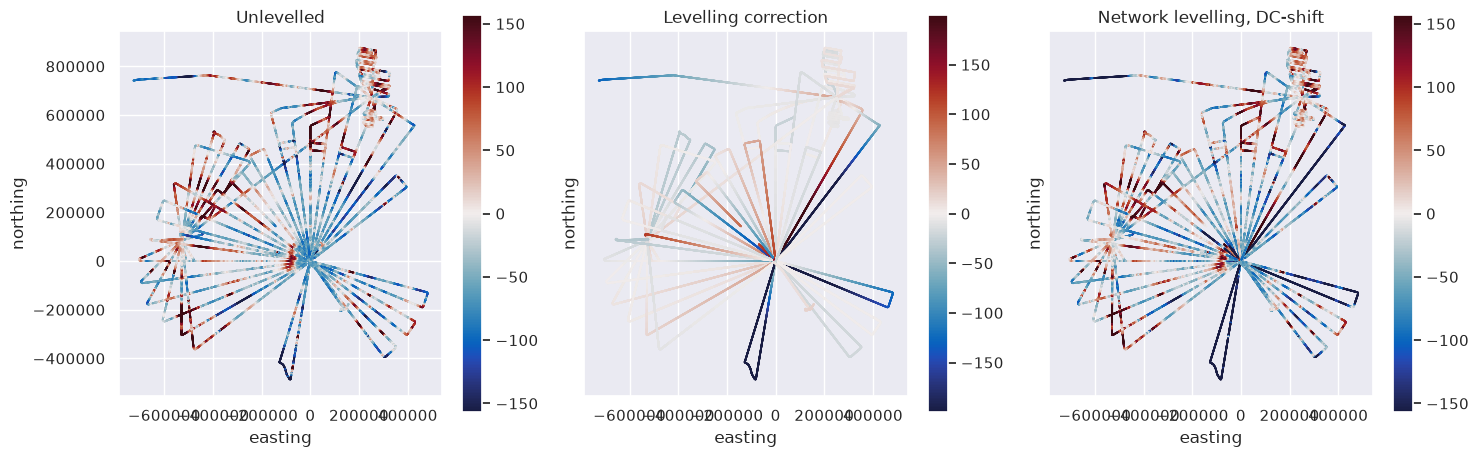

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = data_df.levelled_trend - data_df.unlevelled_tfa
df = data_df

max_abs = vd.maxabs(df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=0.1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

max_abs_level_corr = vd.maxabs(df.levelling_correction, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=0.1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelled_trend",
    s=0.1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Network levelling, DC-shift",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

In [20]:
fig = airbornegeo.plotly_points(
    data_df,
    color_col="levelled_trend",
    hover_cols=["flight"],
    cmap="viridis",
    size=3,
)
fig = airbornegeo.plotly_points(
    inters_trend,
    fig=fig,
    color_col=inters_trend.columns[-1],
    hover_cols=["line1", "line2", "is_buffered"],
    size=8,
    edge_width=0.2,
    cmap="balance",
    robust=False,
)

fig.show()

## Level with a filter

In [ ]:
# Reset to baseline intersections before second branch
survey.intersections = inters
survey.crossover_network_levelling(
    data_col="unlevelled_tfa",
    levelled_col="levelled_filter",
    filter_kwargs={"filter_width": 200e3},
    max_iterations=20,
    plot_dynamic_convergence=True,
)
inters_filter = survey.intersections

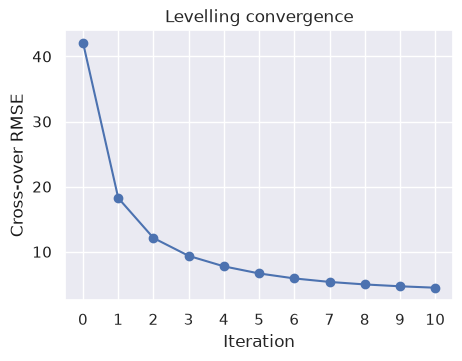

In [22]:
airbornegeo.plot_levelling_convergence(inters_filter)

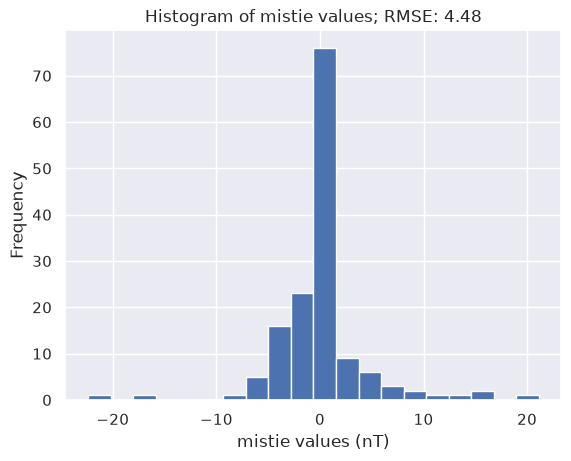

In [23]:
ax = inters_filter[inters_filter.columns[-1]].plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters_filter[inters_filter.columns[-1]]), 2)}"
);

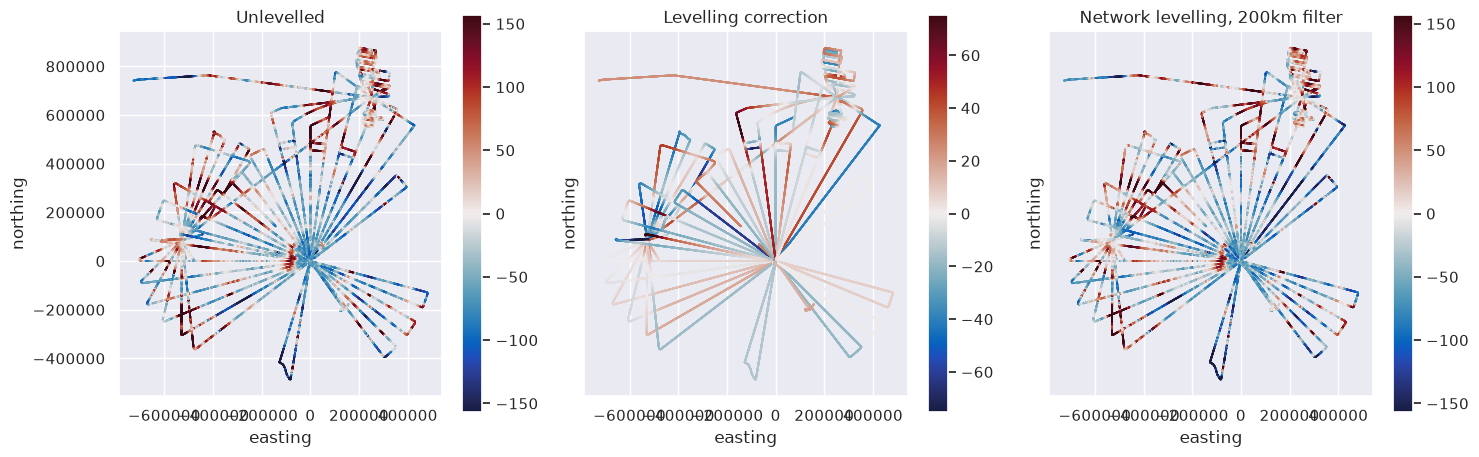

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = data_df.levelled_filter - data_df.unlevelled_tfa
df = data_df

max_abs = vd.maxabs(df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=0.1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

max_abs_level_corr = vd.maxabs(df.levelling_correction, percentile=99.5)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=0.1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelled_filter",
    s=0.1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Network levelling, 200km filter",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

In [25]:
fig = airbornegeo.plotly_points(
    data_df,
    color_col="levelled_filter",
    hover_cols=["flight"],
    cmap="viridis",
    size=3,
)
fig = airbornegeo.plotly_points(
    inters_filter,
    fig=fig,
    color_col=inters_filter.columns[-1],
    hover_cols=["line1", "line2", "is_buffered"],
    size=8,
    edge_width=0.2,
    cmap="balance",
    robust=False,
)

fig.show()